# 土木のためのPython入門④ matplotlib入門編

この記事では、Pythonの代表的な可視化ライブラリ **matplotlib** を使って、土木分野のデータをグラフ化する基本を学びます。

## この記事でできるようになること
- matplotlibとは何かを理解する
- 基本的なグラフを作成する
- 折れ線グラフ・棒グラフ・散布図を作成する
- タイトル、軸ラベル、凡例、グリッドを設定する
- pandasのDataFrameを可視化する
- CSVから読み込んだデータをグラフにする
- グラフを画像として保存する

今回の基本的な流れは、**データを読み込む → 整理する → グラフにする** です。

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

## 日本語フォントについて

日本語を含むグラフでは、環境によって文字化けや四角表示が発生することがあります。

このNotebookでは、本文で推奨している `matplotlib-fontja` を利用する場合に次のセルを実行できます。

In [2]:
# uv環境では事前に `uv add matplotlib-fontja` を実行してください。
import matplotlib_fontja

## 1. 折れ線グラフ

1週間の河川水位を例にします。`plt.plot()` で折れ線グラフを作成できます。

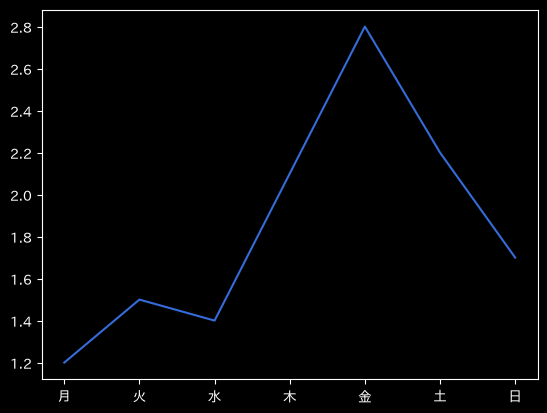

In [3]:
days = ["月", "火", "水", "木", "金", "土", "日"]
water_level = [1.2, 1.5, 1.4, 2.1, 2.8, 2.2, 1.7]

plt.plot(days, water_level)
plt.show()

## 2. タイトルと軸ラベル

グラフの意味が分かるように、タイトルと軸ラベルを設定します。土木分野では特に**単位**を明記することが重要です。

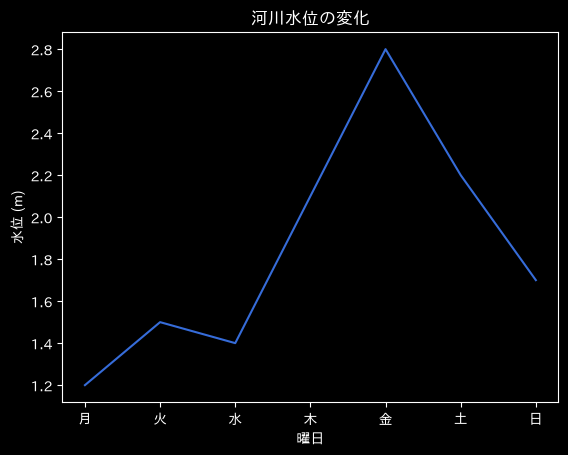

In [4]:
plt.plot(days, water_level)

plt.title("河川水位の変化")
plt.xlabel("曜日")
plt.ylabel("水位 (m)")

plt.show()

## 3. グリッド

`plt.grid()` を使うと、グラフ上の値を読み取りやすくできます。

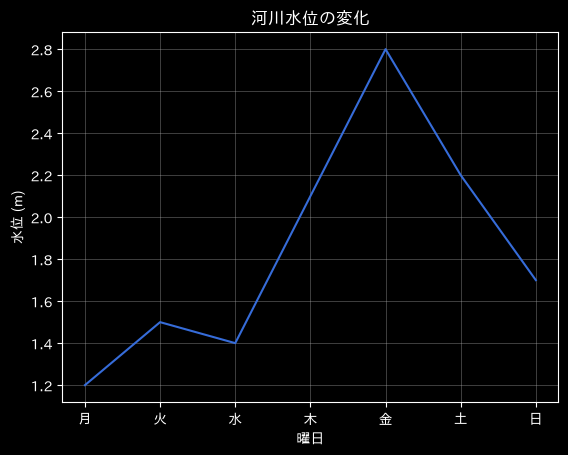

In [5]:
plt.plot(days, water_level)
plt.title("河川水位の変化")
plt.xlabel("曜日")
plt.ylabel("水位 (m)")

plt.grid()
plt.show()

## 4. 凡例

複数のデータを比較するときは、`label=` で名前を指定し、`plt.legend()` で凡例を表示します。

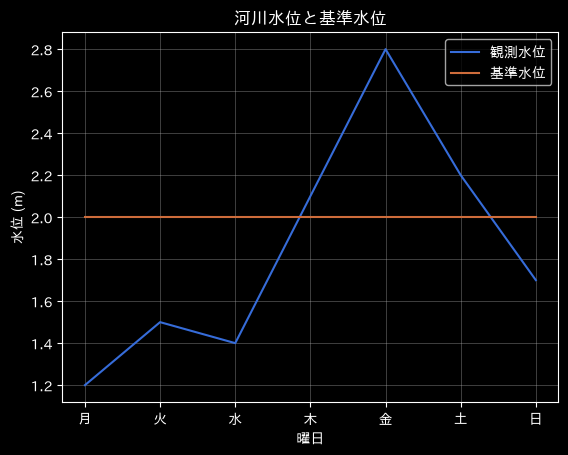

In [6]:
standard_level = [2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0]

plt.plot(days, water_level, label="観測水位")
plt.plot(days, standard_level, label="基準水位")

plt.title("河川水位と基準水位")
plt.xlabel("曜日")
plt.ylabel("水位 (m)")

plt.legend()
plt.grid()
plt.show()

## 5. 棒グラフ

棒グラフは、複数の項目の大きさを比較するときに向いています。

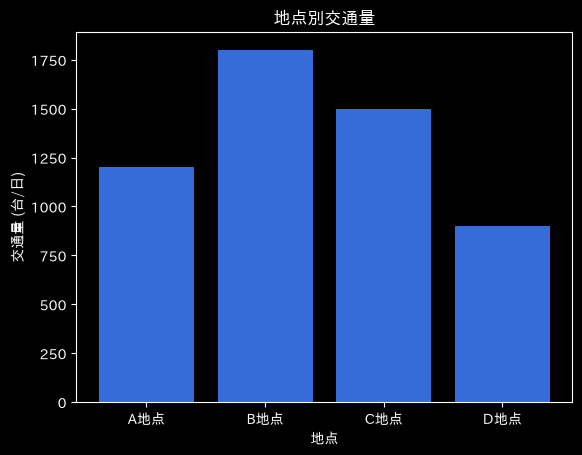

In [7]:
locations = ["A地点", "B地点", "C地点", "D地点"]
traffic = [1200, 1800, 1500, 900]

plt.bar(locations, traffic)

plt.title("地点別交通量")
plt.xlabel("地点")
plt.ylabel("交通量 (台/日)")

plt.show()

## 6. 散布図

散布図は、2つの数値データの関係を見るときに使います。ここでは雨量と河川水位を例にします。

なお、相関が見られても、それだけで因果関係が証明されるわけではありません。実際の土木データでは、統計的な検討や工学的な考察も必要です。

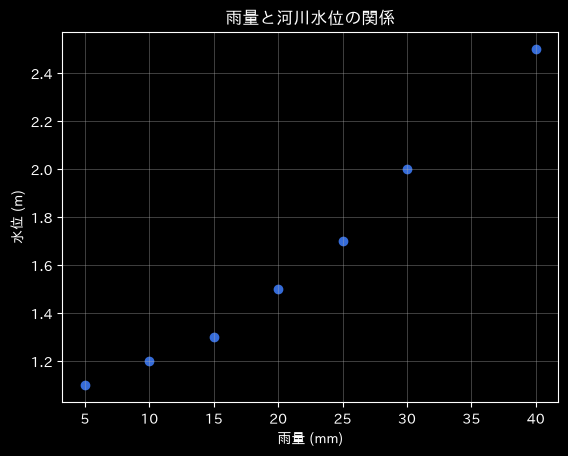

In [8]:
rainfall = [5, 10, 15, 20, 25, 30, 40]
water_level_rain = [1.1, 1.2, 1.3, 1.5, 1.7, 2.0, 2.5]

plt.scatter(rainfall, water_level_rain)

plt.title("雨量と河川水位の関係")
plt.xlabel("雨量 (mm)")
plt.ylabel("水位 (m)")

plt.grid()
plt.show()

## 7. pandasとmatplotlib

実際のデータ分析では、pandasのDataFrameを使ってデータを整理し、そのままmatplotlibで可視化することがよくあります。

In [9]:
river_data = pd.DataFrame(
    {
        "曜日": ["月", "火", "水", "木", "金", "土", "日"],
        "水位(m)": [1.2, 1.5, 1.4, 2.1, 2.8, 2.2, 1.7],
    }
)

print(river_data)

  曜日  水位(m)
0  月    1.2
1  火    1.5
2  水    1.4
3  木    2.1
4  金    2.8
5  土    2.2
6  日    1.7


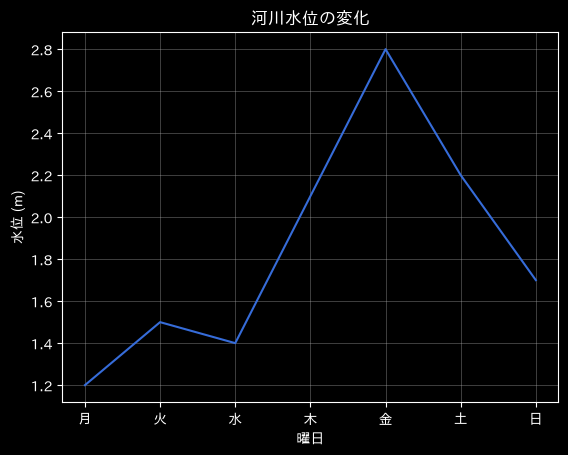

In [10]:
plt.plot(
    river_data["曜日"],
    river_data["水位(m)"]
)

plt.title("河川水位の変化")
plt.xlabel("曜日")
plt.ylabel("水位 (m)")

plt.grid()
plt.show()

## 8. CSVファイルから読み込む

実際のデータ分析では、Pythonコードにデータを直接書くのではなく、CSVファイルなどから読み込むことが多くあります。

例えば `rainfall.csv` が次のような内容だとします。

```text
日,雨量(mm)
1,5
2,12
3,8
4,25
5,40
6,18
7,10
```

Notebookでは再現性を確保するため、次のセルでサンプルCSVを作成してから読み込みます。

In [11]:
csv_data = """日,雨量(mm)
1,5
2,12
3,8
4,25
5,40
6,18
7,10
"""

with open("rainfall.csv", "w", encoding="utf-8") as f:
    f.write(csv_data)

rain_data = pd.read_csv("rainfall.csv")
print(rain_data.head())

   日  雨量(mm)
0  1       5
1  2      12
2  3       8
3  4      25
4  5      40


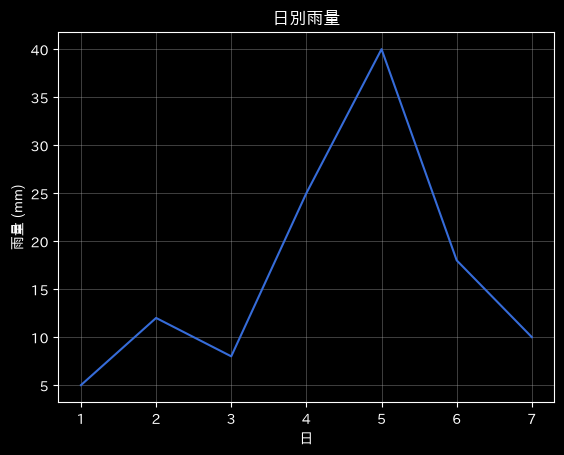

In [12]:
plt.plot(
    rain_data["日"],
    rain_data["雨量(mm)"]
)

plt.title("日別雨量")
plt.xlabel("日")
plt.ylabel("雨量 (mm)")

plt.grid()
plt.show()

## 9. グラフを画像として保存

`plt.savefig()` を使うと、作成したグラフを画像ファイルとして保存できます。レポートや発表資料に利用するときに便利です。

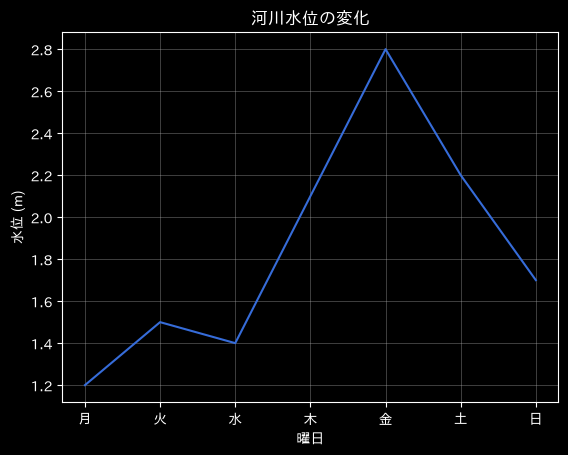

In [13]:
plt.plot(
    river_data["曜日"],
    river_data["水位(m)"]
)

plt.title("河川水位の変化")
plt.xlabel("曜日")
plt.ylabel("水位 (m)")

plt.grid()
plt.savefig("river_water_level.png")
plt.show()

## 10. グラフを作るときの注意点

グラフは、単に作成することが目的ではありません。何を伝えたいのかを考えて作成することが重要です。

- 軸ラベルを付ける
- 単位を明記する
- タイトルを付ける
- 複数データでは必要に応じて凡例を付ける
- 目的に応じてグラフの種類を選ぶ

例えば、時間による変化には折れ線グラフ、項目間の比較には棒グラフ、2つの数値の関係には散布図が適しています。

さらに、雨量と河川水位のようなデータでは、ピークの時間差、観測地点、流域の特性なども考える必要があります。グラフだけから因果関係を断定しないことが重要です。

## 11. AIが生成したグラフコードを検証する

生成AIを使えば、CSVからグラフを作るコードを簡単に生成できます。しかし、コードが実行できることと、結果が工学的に正しいことは別です。

AIが例えば次のコードを生成したとします。

```python
plt.plot(rainfall, water_level)
```

次の点を確認する必要があります。

- 横軸は何か
- 縦軸は何か
- 単位は何か
- データの順番は正しいか
- グラフの種類は適切か
- 欠測値はないか
- グラフから何が言えるか

特に土木分野では、mとcm、m³/sとL/s、台/hと台/日のような単位の違いが結果の意味を大きく変えることがあります。

## 12. 土木分野での活用

matplotlibは、次のようなデータの可視化に利用できます。

### 河川・防災
- 河川水位の時間変化
- 雨量の時間変化
- 流量の変化
- 複数地点の観測データ比較

### 道路・交通
- 時間帯による交通量の変化
- 平日と休日の比較
- 地点ごとの交通量

### 地盤・施工
- 地盤沈下量の変化
- 施工時の計測値
- 測定値のばらつき
- 施工前後の比較

### 構造・実験
- 荷重と変位
- 応力とひずみ
- 振動データ
- 実験結果と理論値

matplotlibは、単にグラフをきれいに作るためだけでなく、データの特徴を把握し、分析や考察につなげるための道具として利用できます。

## 13. データ分析の基本的な流れ

今回までに学んだ内容を組み合わせると、Pythonによるデータ分析の基本的な流れは次のようになります。

```text
データを取得
    ↓
CSVなどから読み込む
    ↓
pandasで整理する
    ↓
必要なデータを抽出する
    ↓
統計量を計算する
    ↓
matplotlibで可視化する
    ↓
データの特徴を確認する
    ↓
土木工学的に考察する
```

例えば河川観測データなら、観測データ → CSV → pandas → 水位・雨量データの整理 → matplotlib → グラフ → 出水時の変化確認、という流れになります。

## 14. まとめ

今回扱った内容は次のとおりです。

- `plt.plot()` による折れ線グラフ
- `plt.bar()` による棒グラフ
- `plt.scatter()` による散布図
- `title()` によるタイトル設定
- `xlabel()`・`ylabel()` による軸ラベル設定
- `grid()` によるグリッド表示
- `legend()` による凡例表示
- `savefig()` によるグラフ保存
- pandasとmatplotlibの組み合わせ
- CSVから読み込んだデータの可視化

pandasではデータを「整理する・抽出する・集計する」ことを学び、matplotlibではそのデータを「グラフにして見る」方法を学びました。

生成AIを利用する場合でも、グラフの種類、軸、単位、データの扱い方、結果の解釈が適切かを判断するための基礎知識は重要です。

次回は **NumPy** を扱い、配列や行列などの数値データを効率的に扱う方法を学びます。